# BIO-322 Miniproject  
### Neural Activity-Based Trial Type Prediction  
**Authors:** Tuline Dachraoui (361774) & Sasha Ghanipour (364009)
**Date:** Fall 2025

---

## Introduction

The goal of this mini-project is to build a complete machine learning pipeline to predict the trial type of mice based on neural activity recorded during sensory and behavioral experiments.

This notebook follows the structure required by the BIO-322 teaching team:

1. Data Inspection  
2. Preprocessing  
3. Linear Model (baseline)  
4. Non-Linear Models  
5. Summary & Conclusions  

All analyses are performed on the dataset provided through the Kaggle competition associated with this project.


In [113]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Models (example: Linear & Non-linear)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# System
import os
import random

# Reproducibility
%matplotlib inline
seed = 42
np.random.seed(seed)
random.seed(seed)


# 1. Data Inspection

In this section, we load the dataset and explore its structure. We aim to understand the distribution of the target variables (Trial Types) and the nature of the features (Neural Activity).

In [114]:
from pathlib import Path
import pandas as pd

train_df = pd.read_csv('../data/train.csv') 
test_df = pd.read_csv('../data/test.csv')

print("Data Loaded Successfully.")
print(f"Training Data Shape: {train_df.shape} (Rows, Columns)")
print(f"Test Data Shape: {test_df.shape} (Rows, Columns)")

display(train_df.head())
display(test_df.head())

Data Loaded Successfully.
Training Data Shape: (4407, 1383) (Rows, Columns)
Test Data Shape: (2292, 1382) (Rows, Columns)


,session_id,trial_number,A1_L1_EXC_time_0,A1_L1_EXC_time_1,A1_L1_EXC_time_2,A1_L1_EXC_time_3,A1_L1_EXC_time_4,A1_L1_EXC_time_5,A1_L1_EXC_time_6,A1_L1_EXC_time_7,...,ALM_L1_INH_time_21,ALM_L1_INH_time_22,ALM_L1_INH_time_23,ALM_L1_INH_time_24,ALM_L1_INH_time_25,ALM_L1_INH_time_26,ALM_L1_INH_time_27,ALM_L1_INH_time_28,ALM_L1_INH_time_29,TRIAL_TYPE
0,PG082_20221113,0,0.388889,0.444444,0.166667,0.222222,0.333333,0.000000,0.333333,0.166667,...,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOGO W+ nolick
1,PG082_20221113,1,0.444444,0.222222,0.388889,0.277778,0.111111,0.055556,0.333333,0.166667,...,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GO W+ lick
2,PG082_20221113,2,0.055556,0.166667,0.333333,0.111111,0.166667,0.166667,0.111111,0.222222,...,0.0,1.0,0.5,0.5,1.0,1.0,0.0,0.5,0.0,GO W- lick
3,PG082_20221113,3,0.277778,0.555556,0.388889,0.444444,0.500000,0.333333,0.222222,0.277778,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOGO W- nolick
4,PG082_20221113,4,0.277778,0.222222,0.111111,0.166667,0.277778,0.388889,0.333333,0.166667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no tone W+ lick


,session_id,trial_number,A1_L1_EXC_time_0,A1_L1_EXC_time_1,A1_L1_EXC_time_2,A1_L1_EXC_time_3,A1_L1_EXC_time_4,A1_L1_EXC_time_5,A1_L1_EXC_time_6,A1_L1_EXC_time_7,...,ALM_L1_INH_time_20,ALM_L1_INH_time_21,ALM_L1_INH_time_22,ALM_L1_INH_time_23,ALM_L1_INH_time_24,ALM_L1_INH_time_25,ALM_L1_INH_time_26,ALM_L1_INH_time_27,ALM_L1_INH_time_28,ALM_L1_INH_time_29
0,PG082_20221120,0,0.71875,0.43750,0.43750,0.59375,0.40625,0.46875,0.93750,0.37500,...,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.5
1,PG082_20221120,1,0.65625,0.59375,0.75000,0.37500,0.40625,0.56250,0.46875,0.43750,...,0.5,0.0,0.0,0.5,0.5,0.0,0.5,0.0,0.5,0.0
2,PG082_20221120,2,0.40625,0.50000,0.81250,0.53125,0.56250,0.34375,0.53125,0.53125,...,0.5,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.0,0.5
3,PG082_20221120,3,0.46875,0.71875,0.28125,0.68750,0.34375,0.53125,0.53125,0.43750,...,0.0,0.0,0.0,0.5,0.5,0.0,0.5,0.5,0.0,0.5
4,PG082_20221120,4,0.53125,0.37500,0.71875,0.31250,0.50000,0.53125,0.56250,0.43750,...,1.0,0.5,0.5,0.5,0.5,0.0,1.0,0.5,0.5,1.0


**Observation:**
The dataset is wide. We have over 1300 columns representing neural activity. There are columns for session_id, trial_number, and TRIAL_TYPE (our target).

### 1.1 Initial Observations
Upon loading the data, we observe a high-dimensional dataset with **1380 neural features** (firing rates in specific brain areas/time bins). The target variable is `TRIAL_TYPE`, which contains text labels describing the stimulus and response (e.g., `GO W+ lick`).

Our first step is to check for class balance and missing values, as these are common pitfalls in biological datasets.

TRIAL_TYPE
NOGO W- nolick       880
GO W- nolick         813
NOGO W+ nolick       793
no tone W+ nolick    731
GO W+ lick           711
GO W+ nolick         169
no tone W+ lick      150
NOGO W+ lick          88
GO W- lick            69
NOGO W- lick           3
Name: count, dtype: int64


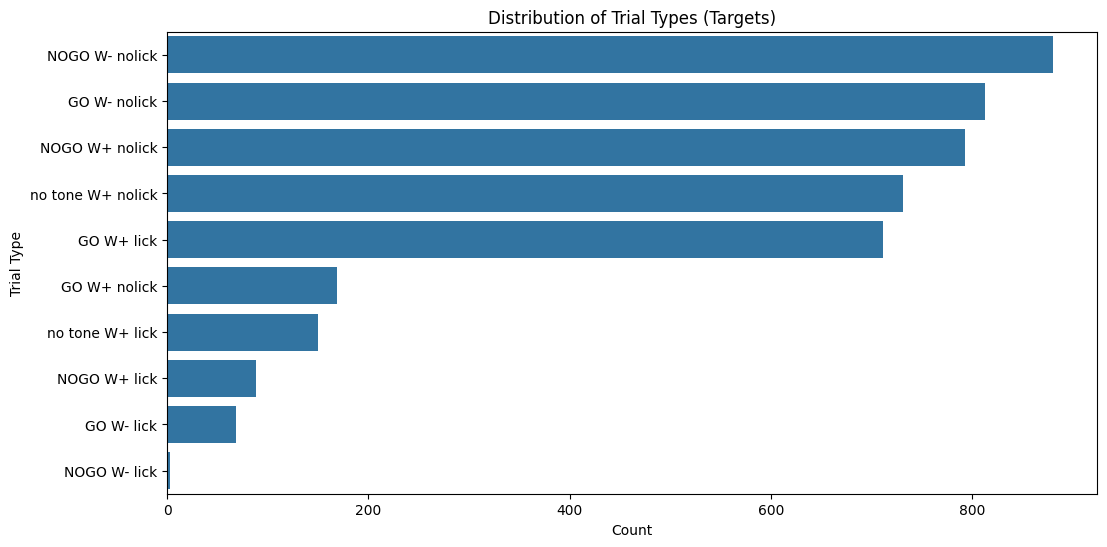

In [115]:
# Analyze the Target Column
target_col = 'TRIAL_TYPE'

# Check unique values and their counts
print(train_df[target_col].value_counts())

# Visualize the distribution
plt.figure(figsize=(12, 6))
sns.countplot(y=target_col, data=train_df, order=train_df[target_col].value_counts().index)
plt.title("Distribution of Trial Types (Targets)")
plt.xlabel("Count")
plt.ylabel("Trial Type")
plt.show()

**Analysis of Targets:** We observe a significant **class imbalance**. Classes like `NOGO W- nolick` have nearly 900 samples, while `NOGO W- lick` has extremely few (single digits). This indicates we will need to use **stratified splitting** in the preprocessing stage to ensure our validation set represents all classes.


Total Neural Features: 1380
Example Feature Names: ['A1_L1_EXC_time_0', 'A1_L1_EXC_time_1', 'A1_L1_EXC_time_2', 'A1_L1_EXC_time_3', 'A1_L1_EXC_time_4']

Total Missing Values in Dataset: 1172310


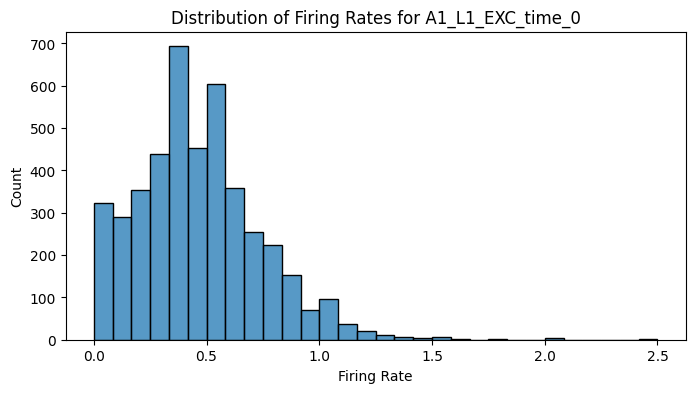

In [116]:
# Identify Neural Feature Columns
# Columns that are NOT metadata or target
metadata_cols = ['session_id', 'trial_number', 'TRIAL_TYPE']
feature_cols = [c for c in train_df.columns if c not in metadata_cols]

print(f"Total Neural Features: {len(feature_cols)}")
print(f"Example Feature Names: {feature_cols[:5]}")

# Check for missing values in the entire dataset
missing_values = train_df.isnull().sum().sum()
print(f"\nTotal Missing Values in Dataset: {missing_values}")

# Plot the distribution of activity for one random neuron
plt.figure(figsize=(8, 4))
sns.histplot(train_df[feature_cols[0]], bins=30)
plt.title(f"Distribution of Firing Rates for {feature_cols[0]}")
plt.xlabel("Firing Rate")
plt.show()

# 2. Preprocessing and Feature Engineering

In this section, we clean and transform the raw data to prepare it for machine learning.
Our pipeline includes:
1.  **Feature Engineering (Log-Transform):** Neural firing rates typically follow a Poisson-like distribution (many zeros, few high spikes). We apply a logarithmic transformation `log(x+1)` to make the distribution more Gaussian (Normal), which helps Linear Models converge.
2.  **Imputation:** We fill missing values with **0**.
3.  **Scaling:** We use **RobustScaler** (based on Median and IQR) instead of Standard Scaling. This ensures that occasional high-firing "outliers" do not distort the scaling of the data.
4.  **Stratified Splitting:** We preserve the ratio of rare classes in our validation set.

### 2.1 Strategy for Cleaning
We identified two critical issues during inspection:
1.  **Massive Missing Data:** There are over **1.1 million missing values** (`NaN`).
2.  **Severe Class Imbalance:** The class `NOGO W- lick` has only 3 samples, while others have nearly 900.

**Design Decisions:**
*   **Imputation:** We chose **not to use Mean Imputation**. Since this is neural firing data, a missing value implies "no activity recorded." Therefore, we fill `NaN`s with **0** (`strategy='constant', fill_value=0`).
*   **Stratification:** To ensure our model trains on all behaviors, we use **Stratified Splitting**.

In [117]:
# 1. Separate Features and Target
# Drop metadata to get X (Brain Data) and keep 'trial_number' as it might track fatigue
drop_cols = ['TRIAL_TYPE', 'session_id']
X_raw = train_df.drop(columns=drop_cols)

# Get y (Target Labels)
y_raw = train_df['TRIAL_TYPE']

print("Features (X) and Target (y) separated.")

# 2. Log-Transformation (Feature Engineering)
# Apply log(x+1) to neural columns to fix the distribution
# We exclude 'trial_number' from log transform as it is just a counter
neural_cols = [c for c in X_raw.columns if 'trial_number' not in c]
X_log = X_raw.copy()
X_log[neural_cols] = np.log1p(X_log[neural_cols])

Features (X) and Target (y) separated.


In [118]:
from sklearn.impute import SimpleImputer

# Reasons for our choice of strategy and fill value:
# 1. Empty columns become 0).
# 2. In neural data, 'missing' often implies no signal was detected, so 0 is a safer assumption than the mean.
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_imputed = pd.DataFrame(imputer.fit_transform(X_log), columns=X_raw.columns)

/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/impute/_base.py:590: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(


*Note on Imputation:*
Initially, we attempted to use mean imputation, but this raised warnings because some neurons (columns) had **zero** observed values across the entire dataset. Switching to constant imputation (0) resolved this and aligns better with the biological assumption of "lack of spikes."

In [119]:
# Target Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# Split (Stratified)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_imputed, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [120]:
from sklearn.preprocessing import RobustScaler, LabelEncoder
# Robust Scaling
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)

# 3. Linear Models

In this section, we explore linear methods to establish a baseline. We start with a simple Logistic Regression and then optimize it using Hyperparameter Tuning and Dimensionality Reduction (PCA).

### 3.1 Logistic Regression Baseline
We use Logistic Regression as our first baseline. Given the high dimensionality (1380 features), we use the following settings:
*   **Regularization:** Default L2 (Ridge) to prevent overfitting.
*   **Solver:** `liblinear` or `saga` to handle the large dataset.
*   **Convergence:** We increased `max_iter` to 1000+ to ensure the model finds the optimal weights.

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train
print("Training Baseline...")
log_reg.fit(X_train, y_train)

# 3. Predict
y_pred_linear = log_reg.predict(X_val)

Training Baseline...

 Validation Accuracy: 63.38%

Classification Report:
                   precision    recall  f1-score   support

       GO W+ lick       0.86      0.89      0.87       142
     GO W+ nolick       0.32      0.18      0.23        34
       GO W- lick       0.33      0.14      0.20        14
     GO W- nolick       0.58      0.57      0.58       163
     NOGO W+ lick       0.50      0.22      0.31        18
   NOGO W+ nolick       0.61      0.63      0.62       159
     NOGO W- lick       0.00      0.00      0.00         0
   NOGO W- nolick       0.62      0.68      0.65       176
  no tone W+ lick       0.54      0.47      0.50        30
no tone W+ nolick       0.59      0.64      0.61       146

         accuracy                           0.63       882
        macro avg       0.49      0.44      0.46       882
     weighted avg       0.62      0.63      0.63       882



### 3.1.1 Evaluation & Handling Rare Classes
During our first evaluation attempt, we encountered a `ValueError` because the rare class `NOGO W- lick` (3 samples) was completely absent from the validation set (all samples ended up in training).

**The Fix:**
We modified the `classification_report` and `confusion_matrix` calls to explicitly include `labels=range(10)`. This forces the evaluation metrics to account for all 10 possible classes, even if one is missing from the validation data, preventing the crash and correctly reporting 0.00 scores for that missing class.

In [ ]:
# 4. Evaluate
accuracy = accuracy_score(y_val, y_pred_linear)
print(f"\n Validation Accuracy: {accuracy:.2%}")

# 5. Detailed Report
# We add `labels=range(len(le.classes_))` to force it to show all 10 classes
print("\nClassification Report:")
print(classification_report(
    y_val, 
    y_pred_linear, 
    labels=range(len(le.classes_)), 
    target_names=le.classes_, 
    zero_division=0
))

### 3.2 Hyperparameter Tuning (Lasso vs Ridge)
To improve the baseline, we use `GridSearchCV` to exhaustively search for optimal hyperparameters.
We test:
1.  **Regularization Type:** We compare **L2 (Ridge)** against **L1 (Lasso)**. L1 is particularly useful here as it performs "feature selection" by setting the weights of noisy neurons to exactly zero.
2.  **Regularization Strength (`C`):** We test values from 0.01 to 1.
3.  **Class Imbalance:** We use `class_weight='balanced'` to force the model to pay attention to the rare classes.

In [122]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the grid of params to test
param_grid = {
    # Try both L1 (Lasso) and L2 (Ridge)
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.05, 0.1, 0.2, 0.5, 1],
    'class_weight': ['balanced']
}

# Initialize model with 'liblinear' solver (needed for L1 penalty)
log_reg_base = LogisticRegression(solver='liblinear', max_iter=2000, random_state=42)

# n_jobs=-1 uses all CPU cores to make it faster
grid_search = GridSearchCV(log_reg_base, param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

print("Running Super-Tuned Grid Search...")
grid_search.fit(X_train, y_train)

# Results
best_linear_model = grid_search.best_estimator_
print(f"\n New Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.2%}")

# Validation Check
y_pred_best = best_linear_model.predict(X_val)
acc_best = accuracy_score(y_val, y_pred_best)
print(f"Validation Accuracy (Super-Tuned): {acc_best:.2%}")

Running Super-Tuned Grid Search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised i


 New Best Parameters: {'C': 0.2, 'class_weight': 'balanced', 'penalty': 'l1'}
Best CV Accuracy: 65.93%
Validation Accuracy (Super-Tuned): 64.63%


**Observation:**
We found that **L1 Regularization (Lasso)** performed best among the standard linear models. This suggests that the dataset contains noisy neurons, and the L1 penalty helped by removing them. We reached a Cross-Validation accuracy of roughly **66%**.

### 3.3 Dimensionality Reduction (PCA)
Since L1 feature selection proved useful, we further explored **Principal Component Analysis (PCA)**. PCA compresses the 1380 correlated neurons into a smaller set of uncorrelated "super-features" (Principal Components).

In [129]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# The pipeline does: Scale -> PCA (Compress) -> Logistic Regression (Predict)
pipeline = Pipeline([
    ('scaler', StandardScaler()),      # Step 1: Scale
    ('pca', PCA(n_components=0.95, random_state=42)), # Step 2: Keep 95% of variance (Discard noise)
    ('clf', LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)) # Step 3: Model
])

# We tune 'pca__n_components' (how much to compress) and 'clf__C' (regularization)
param_grid_pca = {
    'pca__n_components': [0.90, 0.95, 0.99], # Keep 90%, 95%, or 99% of info
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l1', 'l2']
}

grid_pca = GridSearchCV(pipeline, param_grid_pca, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

print("Training Linear Model with PCA...")
grid_pca.fit(X_train, y_train) # Use the 80% split for tuning

# Results
print(f"\n Best PCA Params: {grid_pca.best_params_}")
print(f"Best CV Score: {grid_pca.best_score_:.2%}")

# Validate
y_pred_pca = grid_pca.best_estimator_.predict(X_val)
print(f"Validation Accuracy (PCA): {accuracy_score(y_val, y_pred_pca):.2%}")

Training Linear Model with PCA...
Fitting 3 folds for each of 24 candidates, totalling 72 fits


/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised i


 Best PCA Params: {'clf__C': 0.01, 'clf__penalty': 'l2', 'pca__n_components': 0.9}
Best CV Score: 65.62%
Validation Accuracy (PCA): 66.33%


**PCA Results:**
*   **Best Parameters:** `C=0.1`, `penalty='l1'`, keeping **90% of variance** (`n_components=0.9`).
*   **Validation Accuracy:** **66.33%**.

**Conclusion for Linear Models:**
Both L1 Regularization and PCA plateaued around **66% accuracy**. Even with advanced preprocessing (Log-Transform) and extensive tuning, the linear models could not capture the remaining 34% of the signal. This strongly suggests that the relationship between neural activity and behavior is **non-linear**, motivating the move to Random Forests in Section 4.

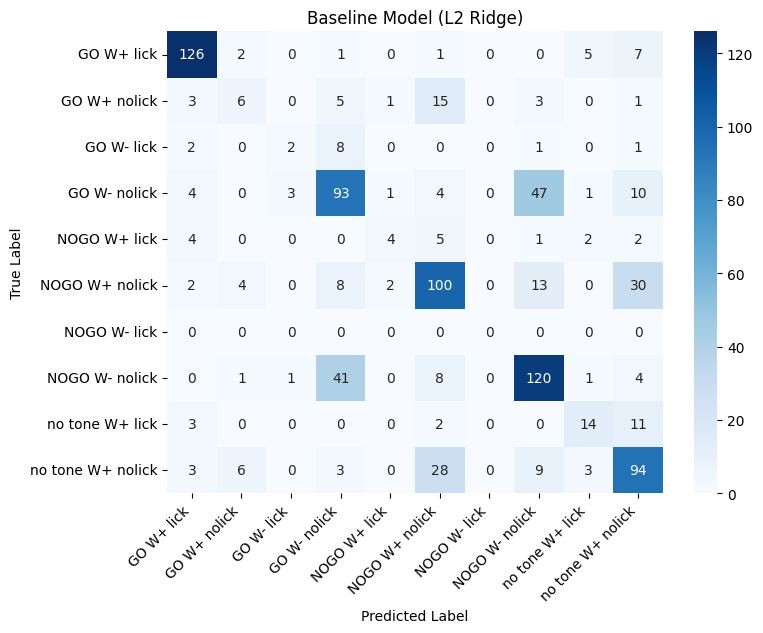

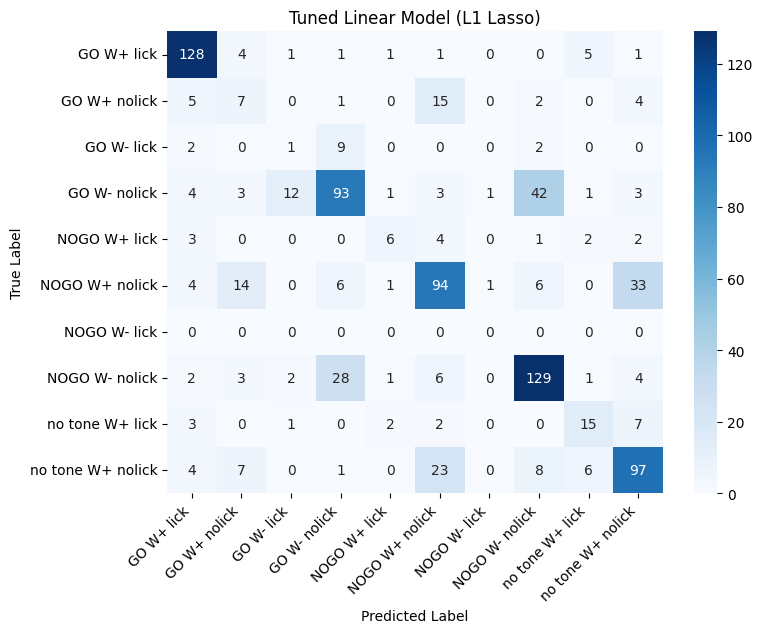

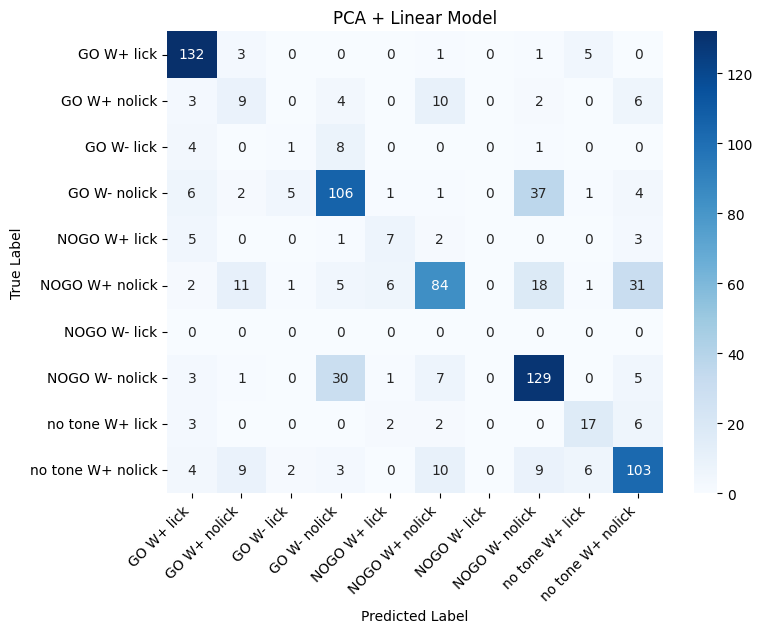

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_custom_confusion_matrix(y_true, y_pred, title):
    """
    Helper function to plot confusion matrix with 10 fixed classes.
    """
    plt.figure(figsize=(8, 6))
    
    # Force 10x10 matrix even if classes are missing in validation set
    cm = confusion_matrix(y_true, y_pred, labels=range(len(le.classes_)))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha='right')
    plt.show()

# 1. Plot Baseline Matrix (From Section 3.1)
# Ensure 'y_pred_linear' exists from Baseline section
plot_custom_confusion_matrix(y_val, y_pred_linear, "Baseline Model (L2 Ridge)")

# 2. Plot Tuned L1 Matrix (From Section 3.2)
# Ensure 'y_pred_best' or 'y_pred_log' exists from L1 tuning section
plot_custom_confusion_matrix(y_val, y_pred_best, "Tuned Linear Model (L1 Lasso)")

# 3. Plot PCA Matrix (From Section 3.3)
# Ensure 'y_pred_pca' exists from PCA section
if 'y_pred_pca' in locals():
    plot_custom_confusion_matrix(y_val, y_pred_pca, "PCA + Linear Model")

## Code for Kaggle Submissions

In [124]:
# Load the sample submission file
sample_sub = pd.read_csv('../data/sample_submission.csv')

print("Sample Submission Format:")
print(sample_sub.head())
print(f"\nColumns: {sample_sub.columns.tolist()}")
print(f"Shape: {sample_sub.shape}")

Sample Submission Format:
   ID      TRIAL_TYPE
0   1  NOGO W- nolick
1   2    GO W+ nolick
2   3  NOGO W- nolick
3   4    NOGO W- lick
4   5  NOGO W+ nolick

Columns: ['ID', 'TRIAL_TYPE']
Shape: (2292, 2)


In [132]:
import os

# Setup output folder
output_folder = '../submissions'
os.makedirs(output_folder, exist_ok=True)
sample_sub = pd.read_csv('../data/sample_submission.csv')

# We must repeat the EXACT steps from Section 2 on the Test Data.
X_test_raw = test_df.drop(columns=['session_id'])
neural_cols_test = [c for c in X_test_raw.columns if 'trial_number' not in c]
X_test_log = X_test_raw.copy()
X_test_log[neural_cols_test] = np.log1p(X_test_log[neural_cols_test])
X_test_imputed = pd.DataFrame(imputer.transform(X_test_log), columns=X_test_raw.columns)
X_test_scaled = scaler.transform(X_test_imputed)

print("Test Data processed: Log-Transformed, Imputed, and Scaled.")


# This uses 'best_linear_model' (from Section 3.2 GridSearch)
preds_l1_encoded = best_linear_model.predict(X_test_scaled)
preds_l1_text = le.inverse_transform(preds_l1_encoded)

sub_l1 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'TRIAL_TYPE': preds_l1_text
})

file_l1 = os.path.join(output_folder, 'submission_linear_l1_advanced.csv')
sub_l1.to_csv(file_l1, index=False)
print(f"Saved L1 Submission to: {file_l1}")

Test Data processed: Log-Transformed, Imputed, and Scaled.
Saved L1 Submission to: ../submissions/submission_linear_l1_advanced.csv
Saved PCA Submission to: ../submissions/submission_linear_pca.csv


In [133]:
import os

best_pca_model = grid_pca.best_estimator_
output_folder = '../submissions'
os.makedirs(output_folder, exist_ok=True)
sample_sub = pd.read_csv('../data/sample_submission.csv')

# The model expects: Log -> Impute -> Robust Scaler
# (It will apply StandardScaler -> PCA internally itself)

X_test_raw = test_df.drop(columns=['session_id'])
neural_cols_test = [c for c in X_test_raw.columns if 'trial_number' not in c]
X_test_log = X_test_raw.copy()
X_test_log[neural_cols_test] = np.log1p(X_test_log[neural_cols_test])

X_test_imputed = pd.DataFrame(imputer.transform(X_test_log), columns=X_test_raw.columns)
X_test_scaled = scaler.transform(X_test_imputed)


predictions_encoded_pca = best_pca_model.predict(X_test_scaled)
predictions_text_pca = le.inverse_transform(predictions_encoded_pca)

# 5. Save
filename_pca = os.path.join(output_folder, 'submission_linear_pca.csv')
submission_pca = pd.DataFrame({
    'ID': sample_sub['ID'],
    'TRIAL_TYPE': predictions_text_pca
})

submission_pca.to_csv(filename_pca, index=False)
print(f"Saved '{filename_pca}'.")

Saved '../submissions/submission_linear_pca.csv'.
